C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



==================== Male Model Training ====================
  Train: 2,855 | Val: 714

==================== Female Model Training ====================
  Train: 4,935 | Val: 1,234
  saved -> ..\results\figures\fig_male_cm.png
  saved -> ..\results\figures\fig_male_cm.pdf


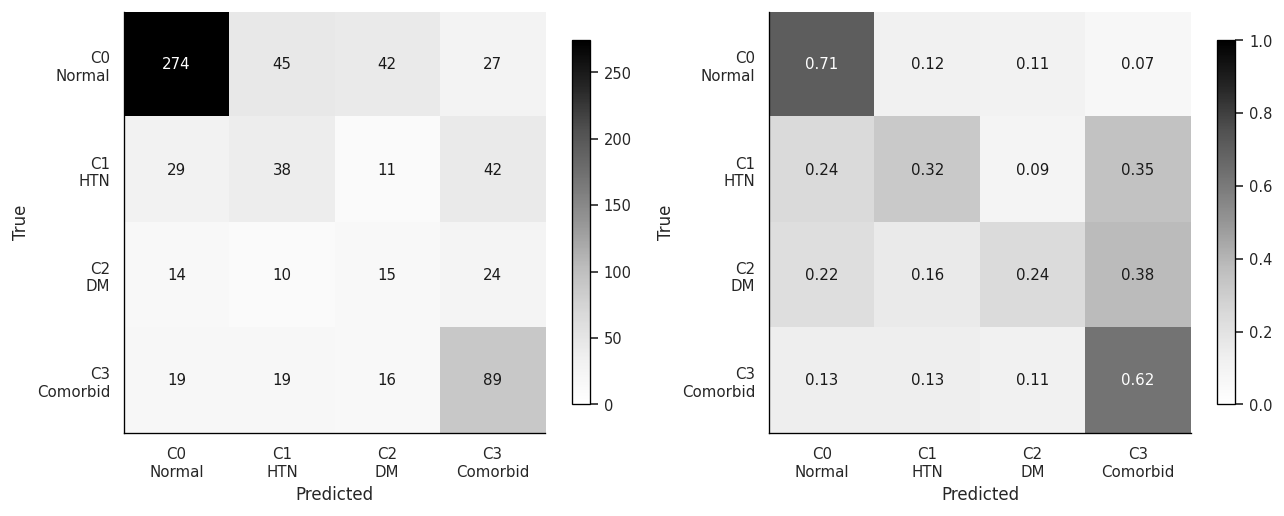

  saved -> ..\results\figures\fig_female_cm.png
  saved -> ..\results\figures\fig_female_cm.pdf


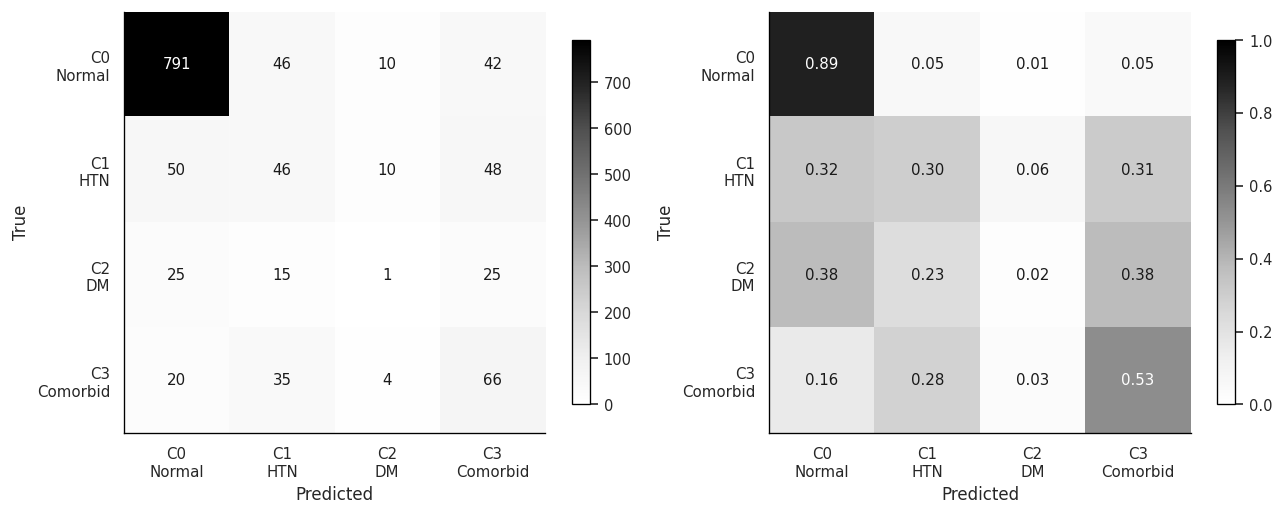

  saved -> ..\results\figures\fig_male_roc.png
  saved -> ..\results\figures\fig_male_roc.pdf


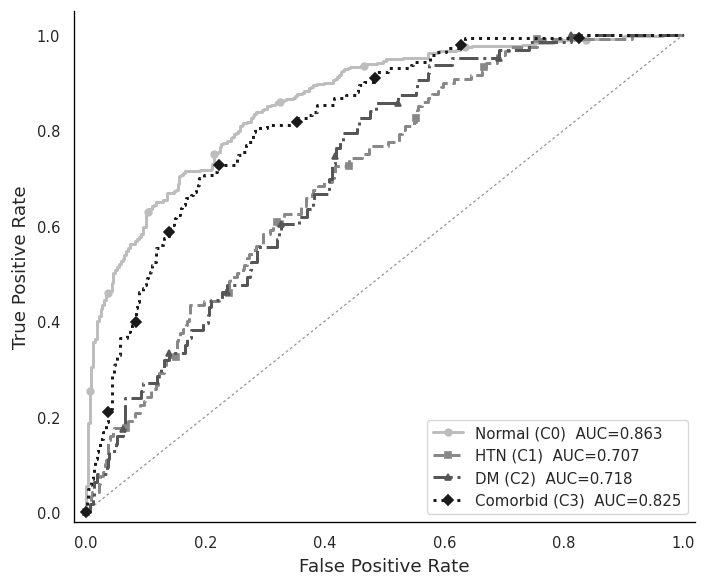

  saved -> ..\results\figures\fig_female_roc.png
  saved -> ..\results\figures\fig_female_roc.pdf


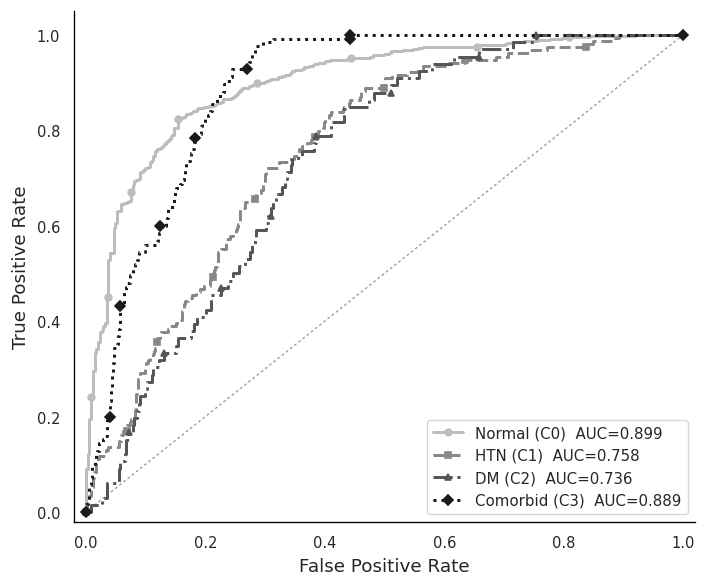

  saved -> ..\results\figures\fig_male_cal.png
  saved -> ..\results\figures\fig_male_cal.pdf


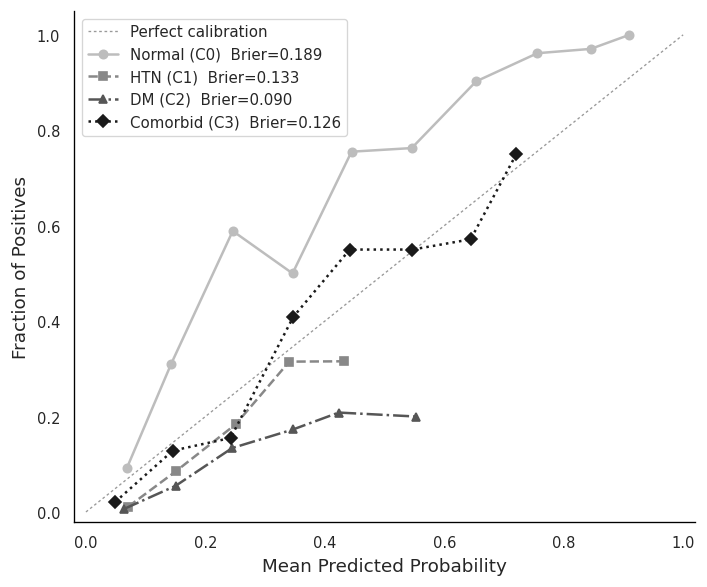

  saved -> ..\results\figures\fig_female_cal.png
  saved -> ..\results\figures\fig_female_cal.pdf


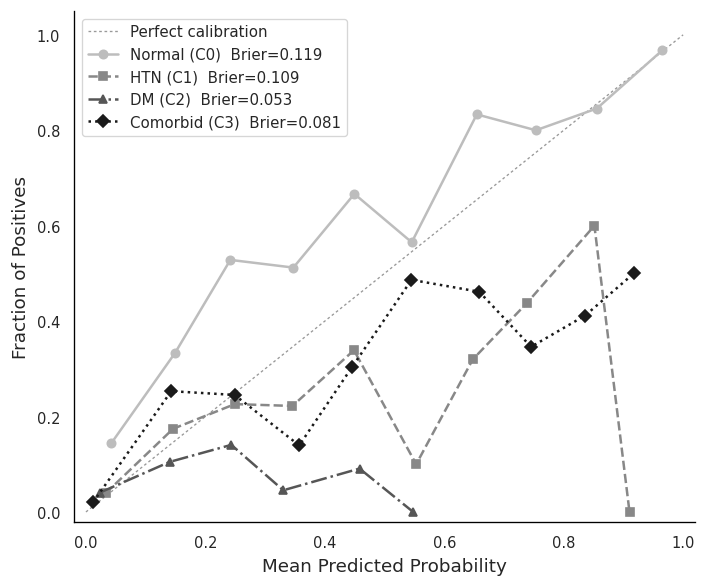


Male classification report:
                    precision    recall  f1-score   support

  Class 0 (Normal)     0.8155    0.7062    0.7569       388
Class 1 (HTN-only)     0.3393    0.3167    0.3276       120
 Class 2 (DM-only)     0.1786    0.2381    0.2041        63
Class 3 (Comorbid)     0.4890    0.6224    0.5477       143

          accuracy                         0.5826       714
         macro avg     0.4556    0.4708    0.4591       714
      weighted avg     0.6139    0.5826    0.5941       714


Female classification report:
                    precision    recall  f1-score   support

  Class 0 (Normal)     0.8928    0.8898    0.8913       889
Class 1 (HTN-only)     0.3239    0.2987    0.3108       154
 Class 2 (DM-only)     0.0400    0.0152    0.0220        66
Class 3 (Comorbid)     0.3646    0.5280    0.4314       125

          accuracy                         0.7326      1234
         macro avg     0.4053    0.4329    0.4139      1234
      weighted avg     0.7227    0.

In [1]:
# 02_xgboost_modeling.ipynb
# Stage 1 of the framework: gender-stratified XGBoost multi-class risk models.
# Trains male and female models (Optuna TPE, weighted-F1), evaluates them on
# the held-out validation set, and produces all Stage-1 figures and tables.
#
# Inputs  (../data/): df_final.pkl, agent_config.pkl
# Outputs (../data/): model_male.pkl, model_female.pkl,
#                     val_male.pkl, val_female.pkl, best_params.pkl
# Figures (../results/figures/): fig_male_cm, fig_female_cm,
#                     fig_male_roc, fig_female_roc,
#                     fig_male_cal, fig_female_cal   (png + pdf, dpi 600)
# Tables  (../results/tables/):  table1_model_performance.tex

import os
import json
import itertools
import joblib
import numpy as np
import pandas as pd

import optuna
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, brier_score_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ----------------------------------------------------------------------------
# Global plotting style: grayscale, publication-ready.
# Figures are saved WITHOUT captions, at dpi=600, as BOTH .png and .pdf.
# Class / curve identity is encoded by GREYSCALE LEVEL + LINE STYLE + MARKER
# + HATCH, never by color, so every figure is legible in black and white.
# ----------------------------------------------------------------------------
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = os.path.join("..", "results", "figures")
TAB_DIR = os.path.join("..", "results", "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

sns.set_theme(style="white", context="paper")
sns.set_palette("Greys")
mpl.rcParams.update({
    "figure.dpi":            120,      # on-screen; saved figures use dpi=600
    "savefig.dpi":           600,
    "font.family":           "DejaVu Sans",
    "font.size":             10,
    "axes.edgecolor":        "#000000",
    "axes.linewidth":        0.8,
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.grid":             False,
    "image.cmap":            "Greys",
})

# Four grayscale levels for the four risk classes (Class 0 -> 3, light -> dark).
GREY_LEVELS = ["#BDBDBD", "#888888", "#565656", "#1A1A1A"]
# Line styles and markers to disambiguate the four classes without color.
LINE_STYLES = ["-", "--", "-.", ":"]
MARKERS     = ["o", "s", "^", "D"]
# Hatches to disambiguate grouped/stacked bars without color.
HATCHES     = ["", "//", "..", "xx", "\\"]
# Two-group grayscale (e.g. Male vs Female, or Pure vs Guardrail).
GREY_PAIR   = ["#9E9E9E", "#3A3A3A"]


def save_fig(fig, name):
    """Save a figure as both PNG and PDF (dpi=600, tight, no caption)."""
    for ext in ("png", "pdf"):
        path = os.path.join(FIG_DIR, f"{name}.{ext}")
        fig.savefig(path, dpi=600, bbox_inches="tight", format=ext)
        print(f"  saved -> {path}")


# ---------------------------------------------------------------------------
# Load preprocessing artefacts
# ---------------------------------------------------------------------------
DATA_DIR = os.path.join("..", "data")
df_final     = joblib.load(os.path.join(DATA_DIR, "df_final.pkl"))
agent_config = joblib.load(os.path.join(DATA_DIR, "agent_config.pkl"))

X_FEATURES = agent_config["X_features"]
TARGET_COL = agent_config["target_col"]

CLASS_LABELS = ["Class 0 (Normal)", "Class 1 (HTN-only)",
                "Class 2 (DM-only)", "Class 3 (Comorbid)"]
SHORT_NAMES  = ["C0\nNormal", "C1\nHTN", "C2\nDM", "C3\nComorbid"]
ROC_LABELS   = ["Normal (C0)", "HTN (C1)", "DM (C2)", "Comorbid (C3)"]


# ---------------------------------------------------------------------------
# Training: 80/20 stratified split, balanced sample weights, Optuna TPE
# ---------------------------------------------------------------------------
def train_model(gender_code, gender_name):
    print(f"\n{'='*20} {gender_name} Model Training {'='*20}")
    df_g = df_final[df_final["Sex"] == gender_code].copy()
    X = df_g[X_FEATURES]
    y = df_g[TARGET_COL].astype(int)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    sw = compute_sample_weight("balanced", y=y_train)
    print(f"  Train: {len(X_train):,} | Val: {len(X_val):,}")

    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
            "max_depth":        trial.suggest_int("max_depth", 3, 7),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "subsample":        trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "objective":        "multi:softprob",
            "num_class":        4,
            "tree_method":      "hist",
            "random_state":     42,
        }
        mdl = xgb.XGBClassifier(**params)
        mdl.fit(X_train, y_train, sample_weight=sw)
        return f1_score(y_val, mdl.predict(X_val), average="weighted")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(objective, n_trials=10)

    best_model = xgb.XGBClassifier(
        **study.best_params, objective="multi:softprob",
        num_class=4, tree_method="hist", random_state=42,
    )
    best_model.fit(X_train, y_train, sample_weight=sw)
    return best_model, study.best_params, X_val, y_val


# ---------------------------------------------------------------------------
# Grayscale confusion matrix (count + row-normalised), no caption
# ---------------------------------------------------------------------------
def plot_confusion(model, X_val, y_val, gender_name, fig_name):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, mat, fmt in zip(axes, [cm, cm_norm], ["d", ".2f"]):
        vmax = mat.max() if fmt == "d" else 1.0
        im = ax.imshow(mat, cmap="Greys", vmin=0, vmax=vmax)
        ax.set_xticks(range(4)); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
        ax.set_yticks(range(4)); ax.set_yticklabels(SHORT_NAMES, fontsize=9)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True", fontsize=10)
        thresh = vmax / 2.0
        for i, j in itertools.product(range(4), range(4)):
            val = mat[i, j]
            txt = f"{val:d}" if fmt == "d" else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                    color="white" if val > thresh else "#1A1A1A")
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


# ---------------------------------------------------------------------------
# Grayscale one-vs-rest ROC: grey level + line style + marker per class
# ---------------------------------------------------------------------------
def plot_roc(model, X_val, y_val, gender_name, fig_name):
    y_prob = model.predict_proba(X_val)
    y_bin = label_binarize(y_val, classes=[0, 1, 2, 3])
    aucs = [roc_auc_score(y_bin[:, c], y_prob[:, c]) for c in range(4)]
    macro_auc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], color="#999999", lw=0.8, ls=(0, (2, 2)))
    for c in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        ax.plot(fpr, tpr, color=GREY_LEVELS[c], lw=1.8,
                ls=LINE_STYLES[c], marker=MARKERS[c], markevery=0.15,
                markersize=4, label=f"{ROC_LABELS[c]}  AUC={aucs[c]:.3f}")
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.legend(fontsize=9, loc="lower right")
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
    plt.tight_layout()
    save_fig(fig, fig_name)
    plt.show()
    return aucs, macro_auc


# ---------------------------------------------------------------------------
# Grayscale calibration (reliability) curves
# ---------------------------------------------------------------------------
def plot_calibration(model, X_val, y_val, gender_name, fig_name):
    y_prob = model.predict_proba(X_val)
    briers = [brier_score_loss((y_val == c).astype(int), y_prob[:, c])
              for c in range(4)]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], color="#999999", lw=0.8, ls=(0, (2, 2)),
            label="Perfect calibration")
    for c in range(4):
        pt, pp = calibration_curve((y_val == c).astype(int),
                                   y_prob[:, c], n_bins=10)
        ax.plot(pp, pt, color=GREY_LEVELS[c], lw=1.5,
                ls=LINE_STYLES[c], marker=MARKERS[c], markersize=5,
                label=f"{ROC_LABELS[c]}  Brier={briers[c]:.3f}")
    ax.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax.set_ylabel("Fraction of Positives", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
    plt.tight_layout()
    save_fig(fig, fig_name)
    plt.show()
    return briers


# ---------------------------------------------------------------------------
# Numeric summary for the LaTeX performance table
# ---------------------------------------------------------------------------
def summarise(model, X_val, y_val, gender_name):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_bin = label_binarize(y_val, classes=[0, 1, 2, 3])
    rep = classification_report(
        y_val, y_pred,
        target_names=["Class0", "Class1", "Class2", "Class3"],
        output_dict=True,
    )
    aucs = [roc_auc_score(y_bin[:, c], y_prob[:, c]) for c in range(4)]
    print(f"\n{gender_name} classification report:")
    print(classification_report(y_val, y_pred, target_names=CLASS_LABELS, digits=4))
    return {
        "gender": gender_name,
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "weighted_f1": f1_score(y_val, y_pred, average="weighted"),
        "macro_auc": roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro"),
        "per_class": {
            f"Class{c}": {
                "precision": rep[f"Class{c}"]["precision"],
                "recall":    rep[f"Class{c}"]["recall"],
                "f1":        rep[f"Class{c}"]["f1-score"],
                "auc":       aucs[c],
            } for c in range(4)
        },
    }


def write_latex_table(summaries, path):
    lines = [
        r"\begin{table}[ht]", r"\centering",
        r"\caption{XGBoost multi-class model performance on the held-out "
        r"validation set (20\% stratified split). P = Precision, R = Recall, "
        r"F1 = F1-score, AUC = One-vs-Rest AUROC.}",
        r"\label{tab:model_performance}",
        r"\begin{tabular}{llcccc}", r"\toprule",
        r"Gender & Class & P & R & F1 & AUC \\", r"\midrule",
    ]
    labels = ["Class 0 (Normal)", "Class 1 (HTN-only)",
              "Class 2 (DM-only)", "Class 3 (Comorbid)"]
    for s in summaries:
        for i, (key, lbl) in enumerate(zip(
                ["Class0", "Class1", "Class2", "Class3"], labels)):
            pc = s["per_class"][key]
            cell = r"\multirow{4}{*}{" + s["gender"] + r"}" if i == 0 else ""
            lines.append(
                f"  {cell} & {lbl} & {pc['precision']:.3f} & {pc['recall']:.3f} "
                f"& {pc['f1']:.3f} & {pc['auc']:.3f} \\\\")
        lines.append(r"  \cmidrule(lr){2-6}")
        lines.append(
            f"  & \\textit{{Macro / Weighted}} & -- & -- & "
            f"{s['macro_f1']:.3f} / {s['weighted_f1']:.3f} & "
            f"{s['macro_auc']:.3f} \\\\")
        lines.append(r"  \midrule")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    print(f"  saved -> {path}")


# ---------------------------------------------------------------------------
# Run: train, evaluate, plot, persist
# ---------------------------------------------------------------------------
model_male,   params_male,   X_val_m, y_val_m = train_model(1.0, "Male")
model_female, params_female, X_val_f, y_val_f = train_model(2.0, "Female")

plot_confusion(model_male,   X_val_m, y_val_m, "Male",   "fig_male_cm")
plot_confusion(model_female, X_val_f, y_val_f, "Female", "fig_female_cm")
plot_roc(model_male,   X_val_m, y_val_m, "Male",   "fig_male_roc")
plot_roc(model_female, X_val_f, y_val_f, "Female", "fig_female_roc")
plot_calibration(model_male,   X_val_m, y_val_m, "Male",   "fig_male_cal")
plot_calibration(model_female, X_val_f, y_val_f, "Female", "fig_female_cal")

summary_male   = summarise(model_male,   X_val_m, y_val_m, "Male")
summary_female = summarise(model_female, X_val_f, y_val_f, "Female")
write_latex_table([summary_male, summary_female],
                  os.path.join(TAB_DIR, "table1_model_performance.tex"))

joblib.dump(model_male,   os.path.join(DATA_DIR, "model_male.pkl"))
joblib.dump(model_female, os.path.join(DATA_DIR, "model_female.pkl"))
joblib.dump({"X_val": X_val_m, "y_val": y_val_m}, os.path.join(DATA_DIR, "val_male.pkl"))
joblib.dump({"X_val": X_val_f, "y_val": y_val_f}, os.path.join(DATA_DIR, "val_female.pkl"))
joblib.dump({"male": params_male, "female": params_female},
            os.path.join(DATA_DIR, "best_params.pkl"))
print("\n>>> models, validation splits, and params saved to ../data/")
